# Building Energy Use Intensity (EUI) Prediction

Pipeline: feature engineering + missing value handling → baseline models (Linear Regression, Random Forest, Gradient Boosting) → a **separate hyperparameter-tuning block per model** → final tuned models → blend → submission. Target: `site_eui` (regression), metric: RMSE.

In [ ]:
# Imports
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb  # used only internally to impute energy_star_rating, not a final model

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="husl")
RANDOM_STATE = 42

In [ ]:
# 1. Load data
from google.colab import drive
drive.mount('/content/drive')

train = pd.read_csv("/content/drive/MyDrive/dataset/energy_dataset/train.csv")
test = pd.read_csv("/content/drive/MyDrive/dataset/energy_dataset/test.csv")
target = "site_eui"
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
print("Train shape:", train.shape, " Test shape:", test.shape)
print("Categorical columns:", cat_cols)

Mounted at /content/drive
Train shape: (75757, 64)  Test shape: (9705, 63)
Categorical columns: ['State_Factor', 'building_class', 'facility_type']


## Exploratory Data Analysis

A quick look at the data before any engineering or modeling — target distribution, missingness, and which features actually move together with `site_eui`.

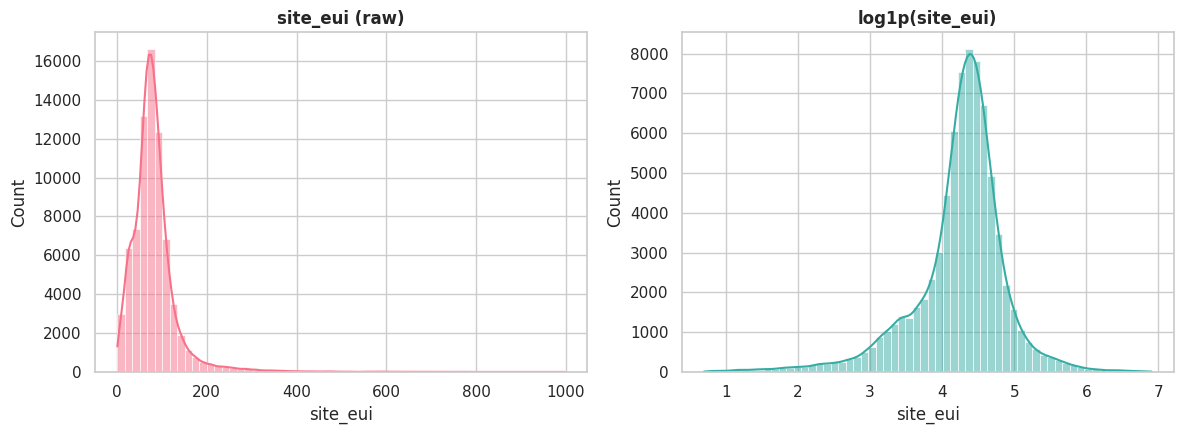

count    75757.000000
mean        82.584693
std         58.255403
min          1.001169
25%         54.528601
50%         75.293716
75%         97.277534
max        997.866120
Name: site_eui, dtype: float64
Skewness (raw): 4.74  | Skewness (log1p): -1.076


In [ ]:
# EDA 1: target distribution (raw vs log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(train[target], bins=60, kde=True, ax=axes[0], color=sns.color_palette("husl", 1)[0])
axes[0].set_title("site_eui (raw)", fontweight="bold")
sns.histplot(np.log1p(train[target]), bins=60, kde=True, ax=axes[1], color=sns.color_palette("husl", 2)[1])
axes[1].set_title("log1p(site_eui)", fontweight="bold")
plt.tight_layout(); plt.show()
print(train[target].describe())
print("Skewness (raw):", round(train[target].skew(), 3),
      " | Skewness (log1p):", round(np.log1p(train[target]).skew(), 3))

**What this tells us:** `site_eui` has a long right tail (a handful of very high-usage buildings), which is exactly why the models train on `log1p(site_eui)` later in this notebook — the log version is far closer to symmetric.

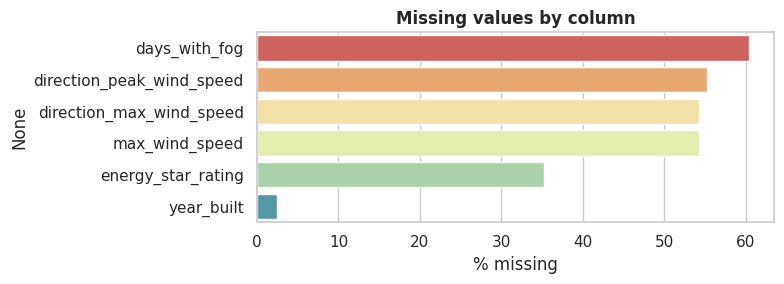

In [ ]:
# EDA 2: missingness by column
miss = (train.isnull().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
plt.figure(figsize=(8, max(3, 0.35 * len(miss))))
sns.barplot(x=miss.values, y=miss.index, hue=miss.index, palette="Spectral", legend=False)
plt.xlabel("% missing"); plt.title("Missing values by column", fontweight="bold")
plt.tight_layout(); plt.show()

**What this tells us:** the weather columns (`days_with_fog`, wind speed/direction) and `energy_star_rating` are the only columns with real missingness — everything else is essentially complete. This is exactly what the imputation strategy in Step 1/2 below is built to handle.

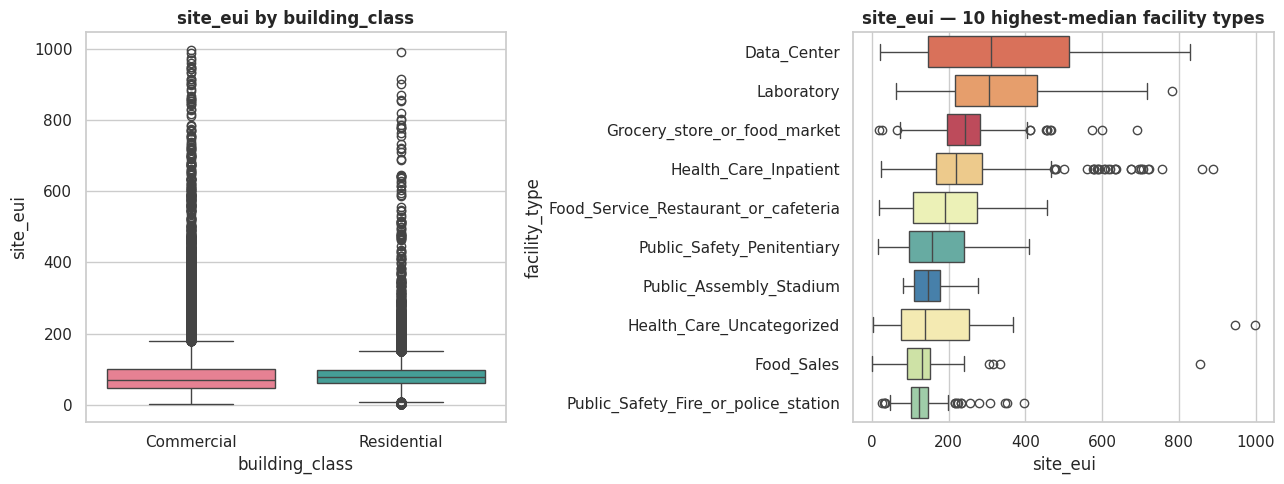

In [ ]:
# EDA 3: target by building_class and top facility_types
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=train, x="building_class", y=target, hue="building_class",
            ax=axes[0], palette="husl", legend=False)
axes[0].set_title("site_eui by building_class", fontweight="bold")

top_facilities = train.groupby("facility_type")[target].median().sort_values(ascending=False).head(10).index
sns.boxplot(data=train[train["facility_type"].isin(top_facilities)],
            x=target, y="facility_type", hue="facility_type", ax=axes[1],
            palette="Spectral", legend=False, order=top_facilities)
axes[1].set_title("site_eui — 10 highest-median facility types", fontweight="bold")
plt.tight_layout(); plt.show()

**What this tells us:** `facility_type` clearly drives energy intensity — some facility types run consistently much higher than others. That's the justification for target-encoding `facility_type` later instead of relying on one-hot alone.

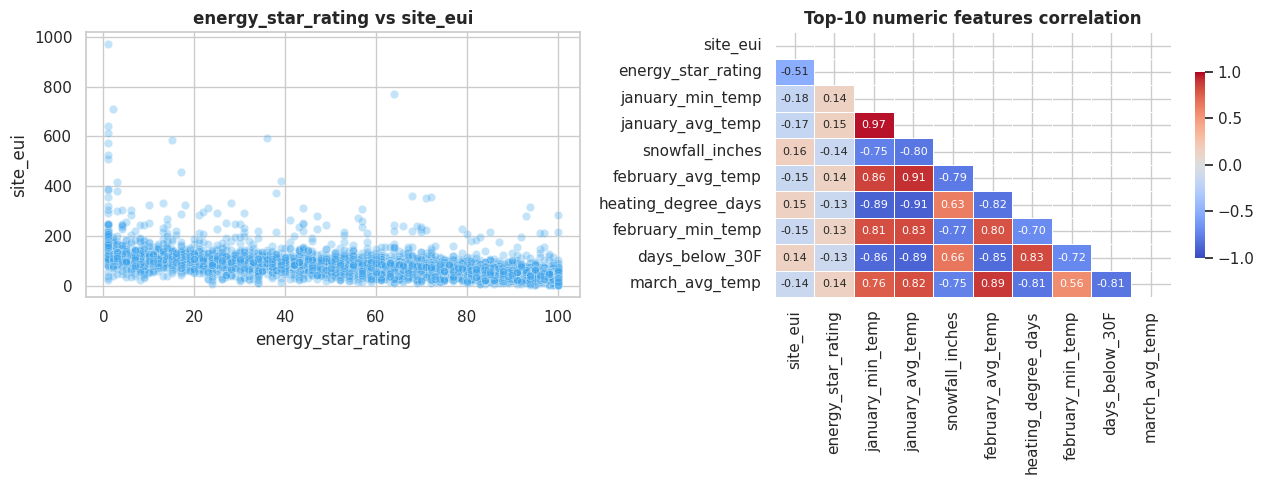

In [ ]:
# EDA 4: energy_star_rating vs target, and correlation heatmap of top numeric features
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample = train.dropna(subset=["energy_star_rating"]).sample(min(5000, train["energy_star_rating"].notnull().sum()), random_state=42)
sns.scatterplot(data=sample, x="energy_star_rating", y=target, alpha=0.3, ax=axes[0], color=sns.color_palette("husl", 3)[2])
axes[0].set_title("energy_star_rating vs site_eui", fontweight="bold")

num = train.select_dtypes(include=[np.number]).drop(columns=["id"], errors="ignore")
top_corr_cols = num.corr()[target].abs().sort_values(ascending=False).head(10).index
corr_matrix = num[top_corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=axes[1], cbar_kws={"shrink": 0.7},
            linewidths=0.5, linecolor="white", annot_kws={"size": 8})
axes[1].set_title("Top-10 numeric features correlation", fontweight="bold")
plt.tight_layout(); plt.show()

**What this tells us:** `energy_star_rating` has a visible negative relationship with `site_eui` (higher efficiency rating → lower energy use), confirming why it's the single most valuable predictor worth the extra effort of predictive imputation rather than a simple median fill. The heatmap shows which numeric features move together with the target most strongly, and flags any pairs of predictors that are highly correlated with each other (redundant information).

## Step 1: Missing Values

- **Weather columns** (`days_with_fog`, `max_wind_speed`, wind direction — 54-60% missing) → filled per `State_Factor` (regional, not global).
- **`energy_star_rating`** (35% missing, the strongest single predictor) → filled with a small LightGBM model trained on the rows where it's known.
- **`year_built`** (2.4% missing) → filled with the median build year for that `facility_type`.

In [ ]:
# Check missing values before handling
print("Missing value % (train):")
print((train.isnull().mean() * 100).sort_values(ascending=False).head(6).round(2))

Missing value % (train):
days_with_fog                60.45
direction_peak_wind_speed    55.19
direction_max_wind_speed     54.23
max_wind_speed               54.23
energy_star_rating           35.26
year_built                    2.42
dtype: float64


## Step 2: Feature Engineering

New features built from the raw columns:
- `building_age` — years since construction (2021 - `year_built`)
- `temp_range_year` — spread between the hottest and coldest monthly averages
- `hdd_cdd_ratio`, `total_degree_days` — combines heating/cooling degree days into ratio and total-load features
- `extreme_cold_days`, `extreme_hot_days` — sums of days below/above various temperature thresholds
- `log_floor_area` — log-transformed floor area (raw floor area is heavily right-skewed)
- `area_x_star_rating`, `age_x_heating_degree_days`, `star_rating_per_area` — interaction terms between building size, age, efficiency rating, and climate load
- `facility_type_te` — out-of-fold target-encoded `facility_type` (captures more signal from this high-cardinality column than one-hot encoding could)

In [ ]:
# 2. Feature engineering + missing value handling
def engineer_and_impute(train, test):
    train, test = train.copy(), test.copy()

    # base engineered features
    for df in (train, test):
        df["building_age"] = 2021 - df["year_built"]
        df.loc[df["building_age"] < 0, "building_age"] = np.nan
        avg_cols = [c for c in df.columns if c.endswith("_avg_temp")]
        df["temp_range_year"] = df[avg_cols].max(axis=1) - df[avg_cols].min(axis=1)
        df["hdd_cdd_ratio"] = df["heating_degree_days"] / (df["cooling_degree_days"] + 1)
        df["total_degree_days"] = df["heating_degree_days"] + df["cooling_degree_days"]
        df["extreme_cold_days"] = (df["days_below_30F"] + df["days_below_20F"]
                                   + df["days_below_10F"] + df["days_below_0F"])
        df["extreme_hot_days"] = (df["days_above_80F"] + df["days_above_90F"]
                                  + df["days_above_100F"] + df["days_above_110F"])
        df["log_floor_area"] = np.log1p(df["floor_area"])

    # group-wise imputation for weather columns (by State_Factor)
    weather_cols = ["days_with_fog", "max_wind_speed", "direction_max_wind_speed",
                     "direction_peak_wind_speed"]
    for c in weather_cols:
        state_median_map = train.groupby("State_Factor")[c].median()
        train[c] = train[c].fillna(train["State_Factor"].map(state_median_map))
        test[c] = test[c].fillna(test["State_Factor"].map(state_median_map))
        global_median = train[c].median()
        train[c] = train[c].fillna(global_median)
        test[c] = test[c].fillna(global_median)

    # predictive imputation for energy_star_rating
    esr_features = [c for c in ["floor_area", "log_floor_area", "building_age", "year_built",
                                 "avg_temp", "heating_degree_days", "cooling_degree_days",
                                 "total_degree_days", "ELEVATION"] if c in train.columns]
    known_mask = train["energy_star_rating"].notnull()
    esr_model = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31,
                                   min_child_samples=30, random_state=RANDOM_STATE, verbose=-1)
    esr_model.fit(train.loc[known_mask, esr_features], train.loc[known_mask, "energy_star_rating"])
    for df in (train, test):
        miss = df["energy_star_rating"].isnull()
        if miss.any():
            df.loc[miss, "energy_star_rating"] = esr_model.predict(df.loc[miss, esr_features])

    # year_built: median by facility_type, then rebuild building_age
    fill_map = train.groupby("facility_type")["year_built"].median()
    for df in (train, test):
        df["year_built"] = df["year_built"].fillna(df["facility_type"].map(fill_map))
        df["year_built"] = df["year_built"].fillna(train["year_built"].median())
        df["building_age"] = 2021 - df["year_built"]
        df.loc[df["building_age"] < 0, "building_age"] = np.nan
        df["building_age"] = df["building_age"].fillna(df["building_age"].median())

    # interaction features
    for df in (train, test):
        df["area_x_star_rating"] = df["floor_area"] * df["energy_star_rating"]
        df["age_x_heating_degree_days"] = df["building_age"] * df["heating_degree_days"]
        df["star_rating_per_area"] = df["energy_star_rating"] / (df["log_floor_area"] + 1)

    return train, test

train_fe, test_fe = engineer_and_impute(train, test)

# out-of-fold target encoding for facility_type (high-cardinality categorical)
kf_te = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_fe["facility_type_te"] = np.nan
global_mean = train_fe[target].mean()
for tr_idx, va_idx in kf_te.split(train_fe):
    fold_means = train_fe.iloc[tr_idx].groupby("facility_type")[target].mean()
    train_fe.loc[train_fe.index[va_idx], "facility_type_te"] = \
        train_fe.iloc[va_idx]["facility_type"].map(fold_means).values
train_fe["facility_type_te"] = train_fe["facility_type_te"].fillna(global_mean)
full_facility_means = train_fe.groupby("facility_type")[target].mean()
test_fe["facility_type_te"] = test_fe["facility_type"].map(full_facility_means).fillna(global_mean)

print("Missing values remaining (train):", train_fe.drop(columns=[target]).isnull().sum().sum())
print("Missing values remaining (test):", test_fe.isnull().sum().sum())
print("Engineered feature count:", train_fe.shape[1] - train.shape[1])

Missing values remaining (train): 0
Missing values remaining (test): 0
Engineered feature count: 11


## Step 3: Encode Categoricals

`State_Factor` and `building_class` (low cardinality) → one-hot encoded. `facility_type` (high cardinality) → dropped in favor of the `facility_type_te` target-encoded column already built above.

In [ ]:
# 3. One-hot encode low-cardinality categoricals; drop raw facility_type
onehot_cols = ["State_Factor", "building_class"]
train_ohe = pd.get_dummies(train_fe, columns=onehot_cols, drop_first=True)
test_ohe = pd.get_dummies(test_fe, columns=onehot_cols, drop_first=True)
train_ohe, test_ohe = train_ohe.align(test_ohe, join="left", axis=1, fill_value=0)

drop = [target, "id", "facility_type"]
features = [c for c in train_ohe.columns if c not in drop]
X = train_ohe[features].astype(float)
y = train_fe[target]
X_test = test_ohe[features].astype(float)
y_log = np.log1p(y)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Feature count:", len(features))

Feature count: 77


## Step 4: Baseline Models

Each model trained with its default/simple hyperparameters first, 5-fold CV on `log1p(site_eui)`. These numbers are the reference point the tuned versions below need to beat.

In [ ]:
# 4a. Baseline: Linear Regression (Ridge with alpha=1.0 as the default baseline)
oof_lr_base = np.zeros(len(X))
for fold, (tr, va) in enumerate(kf.split(X), 1):
    pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
    pipe.fit(X.iloc[tr], y_log.iloc[tr])
    oof_lr_base[va] = pipe.predict(X.iloc[va])

oof_lr_base = np.expm1(oof_lr_base)
rmse_lr_base = np.sqrt(mean_squared_error(y, oof_lr_base))
r2_lr_base = r2_score(y, oof_lr_base)
print(f"Baseline Linear Regression  RMSE={rmse_lr_base:.4f}  R2={r2_lr_base:.4f}")

Baseline Linear Regression  RMSE=49.9068  R2=0.2661


In [ ]:
# 4b. Baseline: Random Forest (simple default-ish settings)
oof_rf_base = np.zeros(len(X))
for fold, (tr, va) in enumerate(kf.split(X), 1):
    model = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X.iloc[tr], y_log.iloc[tr])
    oof_rf_base[va] = model.predict(X.iloc[va])

oof_rf_base = np.expm1(oof_rf_base)
rmse_rf_base = np.sqrt(mean_squared_error(y, oof_rf_base))
r2_rf_base = r2_score(y, oof_rf_base)
print(f"Baseline Random Forest      RMSE={rmse_rf_base:.4f}  R2={r2_rf_base:.4f}")

Baseline Random Forest      RMSE=44.3873  R2=0.4194


In [ ]:
# 4c. Baseline: Gradient Boosting (simple default-ish settings)
oof_gb_base = np.zeros(len(X))
for fold, (tr, va) in enumerate(kf.split(X), 1):
    model = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE)
    model.fit(X.iloc[tr], y_log.iloc[tr])
    oof_gb_base[va] = model.predict(X.iloc[va])

oof_gb_base = np.expm1(oof_gb_base)
rmse_gb_base = np.sqrt(mean_squared_error(y, oof_gb_base))
r2_gb_base = r2_score(y, oof_gb_base)
print(f"Baseline Gradient Boosting  RMSE={rmse_gb_base:.4f}  R2={r2_gb_base:.4f}")

Baseline Gradient Boosting  RMSE=46.0452  R2=0.3753


In [ ]:
# Baseline summary
baseline_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse_lr_base, rmse_rf_base, rmse_gb_base],
    "R2": [r2_lr_base, r2_rf_base, r2_gb_base],
}).sort_values("RMSE").reset_index(drop=True)
baseline_summary

,Model,RMSE,R2
0,Random Forest,44.387257,0.419436
1,Gradient Boosting,46.045165,0.375257
2,Linear Regression,49.906814,0.266073


## Step 5: Hyperparameter Tuning (one block per model)

Each model gets its own `RandomizedSearchCV` block, searching over the hyperparameters that matter most for that algorithm, scored by RMSE with 3-fold CV (kept at 3 folds instead of 5 purely to keep search time reasonable — the final models below are re-fit with full 5-fold CV once the best settings are found).

In [ ]:
# 5a. Hyperparameter tuning: Linear Regression (Ridge alpha)
ridge_param_grid = {
    "ridge__alpha": [0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0],
}
ridge_pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])

ridge_search = RandomizedSearchCV(
    ridge_pipe, ridge_param_grid, n_iter=8, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
ridge_search.fit(X, y_log)

print("Best Ridge params:", ridge_search.best_params_)
print("Best CV RMSE (log space):", -ridge_search.best_score_)
best_lr_params = ridge_search.best_params_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Ridge params: {'ridge__alpha': 10.0}
Best CV RMSE (log space): 0.5471577614893723


In [ ]:
# 5b. Hyperparameter tuning: Random Forest
rf_param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [10, 14, 18, 22, None],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", 0.5, 0.8],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    rf_param_grid, n_iter=12, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X, y_log)

print("Best Random Forest params:", rf_search.best_params_)
print("Best CV RMSE (log space):", -rf_search.best_score_)
best_rf_params = rf_search.best_params_

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [ ]:
# 5c. Hyperparameter tuning: Gradient Boosting
gb_param_grid = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
}
gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_param_grid, n_iter=12, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
gb_search.fit(X, y_log)

print("Best Gradient Boosting params:", gb_search.best_params_)
print("Best CV RMSE (log space):", -gb_search.best_score_)
best_gb_params = gb_search.best_params_

## Step 6: Final Tuned Models (5-fold CV)

Re-fitting each model with its best hyperparameters, this time with full 5-fold CV to get honest out-of-fold predictions for the final comparison and blend.

In [ ]:
# 6a. Final tuned Linear Regression
oof_lr = np.zeros(len(X))
test_lr = np.zeros(len(X_test))
for fold, (tr, va) in enumerate(kf.split(X), 1):
    pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(**{k.replace("ridge__", ""): v for k, v in best_lr_params.items()}))])
    pipe.fit(X.iloc[tr], y_log.iloc[tr])
    oof_lr[va] = pipe.predict(X.iloc[va])
    test_lr += pipe.predict(X_test) / kf.n_splits

oof_lr, test_lr = np.expm1(oof_lr), np.expm1(test_lr)
rmse_lr = np.sqrt(mean_squared_error(y, oof_lr))
r2_lr = r2_score(y, oof_lr)
print(f"Tuned Linear Regression  RMSE={rmse_lr:.4f}  R2={r2_lr:.4f}  (baseline was RMSE={rmse_lr_base:.4f})")

In [ ]:
# 6b. Final tuned Random Forest
oof_rf = np.zeros(len(X))
test_rf = np.zeros(len(X_test))
for fold, (tr, va) in enumerate(kf.split(X), 1):
    model = RandomForestRegressor(**best_rf_params, n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X.iloc[tr], y_log.iloc[tr])
    oof_rf[va] = model.predict(X.iloc[va])
    test_rf += model.predict(X_test) / kf.n_splits

oof_rf, test_rf = np.expm1(oof_rf), np.expm1(test_rf)
rmse_rf = np.sqrt(mean_squared_error(y, oof_rf))
r2_rf = r2_score(y, oof_rf)
print(f"Tuned Random Forest      RMSE={rmse_rf:.4f}  R2={r2_rf:.4f}  (baseline was RMSE={rmse_rf_base:.4f})")

In [ ]:
# 6c. Final tuned Gradient Boosting
oof_gb = np.zeros(len(X))
test_gb = np.zeros(len(X_test))
for fold, (tr, va) in enumerate(kf.split(X), 1):
    model = GradientBoostingRegressor(**best_gb_params, random_state=RANDOM_STATE)
    model.fit(X.iloc[tr], y_log.iloc[tr])
    oof_gb[va] = model.predict(X.iloc[va])
    test_gb += model.predict(X_test) / kf.n_splits

oof_gb, test_gb = np.expm1(oof_gb), np.expm1(test_gb)
rmse_gb = np.sqrt(mean_squared_error(y, oof_gb))
r2_gb = r2_score(y, oof_gb)
print(f"Tuned Gradient Boosting  RMSE={rmse_gb:.4f}  R2={r2_gb:.4f}  (baseline was RMSE={rmse_gb_base:.4f})")

## Step 7: Compare and Blend

Comparing all baseline and tuned models together, then blending the three tuned models (simple average and a Ridge meta-blend that learns per-model weights from the out-of-fold predictions).

In [ ]:
# 7. Full comparison + blend
oof_avg = (oof_lr + oof_rf + oof_gb) / 3
test_avg = (test_lr + test_rf + test_gb) / 3
rmse_avg = np.sqrt(mean_squared_error(y, oof_avg))
r2_avg = r2_score(y, oof_avg)

oof_stack = np.column_stack([oof_lr, oof_rf, oof_gb])
test_stack = np.column_stack([test_lr, test_rf, test_gb])
ridge_blend = Ridge(alpha=1.0, positive=True)
ridge_blend.fit(oof_stack, y)
oof_ridge = ridge_blend.predict(oof_stack)
test_ridge = ridge_blend.predict(test_stack)
rmse_ridge = np.sqrt(mean_squared_error(y, oof_ridge))
r2_ridge = r2_score(y, oof_ridge)

comparison = pd.DataFrame({
    "Model": ["Linear Regression (baseline)", "Random Forest (baseline)", "Gradient Boosting (baseline)",
              "Linear Regression (tuned)", "Random Forest (tuned)", "Gradient Boosting (tuned)",
              "Simple Avg Blend (tuned)", "Ridge Blend (tuned)"],
    "RMSE": [rmse_lr_base, rmse_rf_base, rmse_gb_base, rmse_lr, rmse_rf, rmse_gb, rmse_avg, rmse_ridge],
    "R2": [r2_lr_base, r2_rf_base, r2_gb_base, r2_lr, r2_rf, r2_gb, r2_avg, r2_ridge],
}).sort_values("RMSE").reset_index(drop=True)

print("Ridge blend weights (LR, RF, GB):", ridge_blend.coef_.round(3))
comparison

## Step 8: Build Submission

Uses whichever model/blend scored the lowest out-of-fold RMSE in the comparison table above (from the tuned models and blends only, since those are the ones with test-set predictions available).

In [ ]:
# 8. Final submission
test_preds = {
    "Linear Regression (tuned)": test_lr, "Random Forest (tuned)": test_rf, "Gradient Boosting (tuned)": test_gb,
    "Simple Avg Blend (tuned)": test_avg, "Ridge Blend (tuned)": test_ridge,
}
tuned_comparison = comparison[comparison["Model"].isin(test_preds.keys())].reset_index(drop=True)
best_name = tuned_comparison.iloc[0]["Model"]
best_test_pred = test_preds[best_name]
print(f"Best model/blend by OOF RMSE: {best_name}  (RMSE={tuned_comparison.iloc[0]['RMSE']:.4f}, R2={tuned_comparison.iloc[0]['R2']:.4f})")

sample = pd.read_csv("/content/drive/MyDrive/dataset/energy_dataset/sample_solution.csv")
sub = pd.DataFrame({"id": test["id"], "site_eui": np.clip(best_test_pred, 1, None)})
sub = sample[["id"]].merge(sub, on="id", how="left")
sub.to_csv("submission.csv", index=False)
print("Saved submission.csv, rows:", len(sub))
sub.head()